# Initialize cosmocnc

In [19]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Limit to 1 thread
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import cosmocnc
from cosmocnc.cnc import cluster_number_counts
from cosmocnc.params import cnc_params_default, cosmo_params_default, scaling_relation_params_default
import jax.numpy as jnp
import jax
import tszpower as tsz
# -------------------------
# 1) Configure cosmocnc params
# -------------------------
cnc_params = cnc_params_default.copy()

# Theory-only (no catalogue needed)
cnc_params["load_catalogue"] = False
# cnc_params["cluster_catalogue"] = "SO_sim_0"

# Backends
cnc_params["cosmology_tool"] = "classy_sz"
cnc_params["hmf_calc"] = "cnc"
# cnc_params["hmf_calc"] = "classy_sz"

cnc_params["survey_sr"] = "/scratch/scratch-lxu/cosmocnc/surveys/survey_sr_planck_sim.py"
cnc_params["survey_cat"] = "/scratch/scratch-lxu/cosmocnc/surveys/survey_cat_so_sim.py"

# Selection observable
cnc_params["obs_select"] = "q_planck_sim"
cnc_params["observables"] = [["q_planck_sim"]]
cnc_params["interp_tinker"] = "log"

# Ranges
cnc_params["M_min"] = 1e14
cnc_params["M_max"] = 1e16
cnc_params["z_min"] = 0.005
cnc_params["z_max"] = 2.0
cnc_params["obs_select_min"] = 5.0
cnc_params["obs_select_max"] = 200.0

# Resolution
cnc_params["n_points"] = 16384 #number of points in which the mass function at each redshift (and all the convolutions) is evaluated
cnc_params["n_points_data_lik"] = 4096 #number of points in which the mass function at each redshift (and all the convolutions) is evaluated
cnc_params["n_z"] = 4096

#Parameters for the binned likelihood

cnc_params["binned_lik_type"] = "z_and_obs_select"
cnc_params["bins_edges_z"] = np.linspace(cnc_params["z_min"],cnc_params["z_max"],20)
cnc_params["bins_edges_obs_select"] = np.exp(np.linspace(np.log(cnc_params["obs_select_min"]),np.log(cnc_params["obs_select_max"]),20))

#Stacked data, set to False for now

cnc_params["stacked_likelihood"] = False
cnc_params["stacked_data"] = ["p_so_sim_stacked"] #list of stacked data
cnc_params["compute_stacked_cov"] = True


cnc_params["data_lik_from_abundance"] = False
cnc_params["likelihood_type"] = "binned"

# Quiet logs
cnc_params["cosmocnc_verbose"] = "minimal"

In [20]:
cnc = cosmocnc.cluster_number_counts(cnc_params = cnc_params)
cnc.initialise()

/scratch/scratch-lxu/cosmocnc/cosmocnc/cnc.py:65: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


# Initialize tszpower

In [21]:
allpars = {
    'omega_b': 0.022245895720000002,
    'omega_cdm':  0.12085104428000001,
    'H0': 67.4,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 3.037195662,
    # 'sigma8': 0.81,
    'n_s': 0.96,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.61,

    'M_min': 1e14*0.674,
    'M_max': 1e16*0.674,

    'z_min' : 0.005,
    'z_max' : 2.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 1, 
}
tsz.classy_sz.set(allpars)
tsz.initialise()

/tmp/ipykernel_3588881/925258036.py:27: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  tsz.initialise()


# Update scaling relation parameters

In [22]:
scal_rel_params = scaling_relation_params_default.copy()
scal_rel_params["A_szifi"] = -4.218089337196837
scal_rel_params["alpha_szifi"] = 1.12

cnc.update_params(cosmo_params_default, scal_rel_params)

/scratch/scratch-lxu/cosmocnc/cosmocnc/cnc.py:138: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


# Cluster abundance in cosmocnc

In [23]:
cnc.get_number_counts()
cnc.get_cluster_abundance()
cnc.get_abundance_matrix()

In [24]:
cnc.n_tot

np.float64(1446.4477009526015)

In [25]:
cnc.get_log_lik_binned()

0.0

In [26]:
cnc_params["likelihood_type"] = "binned"
cnc_params["obs_select_min"] = 5.000

bins_centres_z = cnc.bins_centres_z #z bins centres
bins_centres_snr = cnc.bins_centres_obs #SNR bins centres

n_binned_theory = cnc.n_binned
n_tot_bins_theory = np.sum(n_binned_theory)
n_binned_snr_theory = np.sum(n_binned_theory,axis=0)
n_binned_z_theory = np.sum(n_binned_theory,axis=1)
print("Predicted total number of clusters in the bins = ",n_tot_bins_theory,"+-",np.sqrt(n_tot_bins_theory))

Predicted total number of clusters in the bins =  1446.1937742133546 +- 38.028854495150846


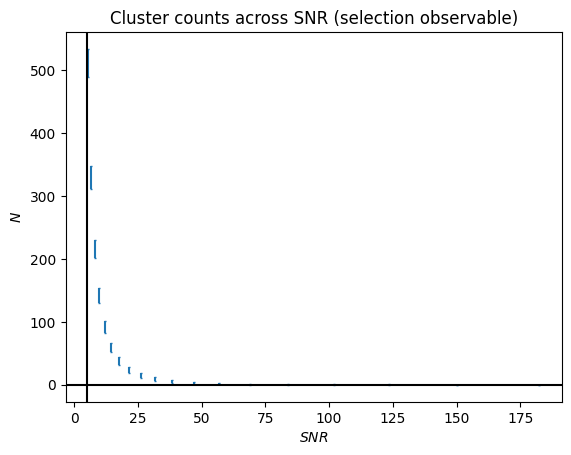

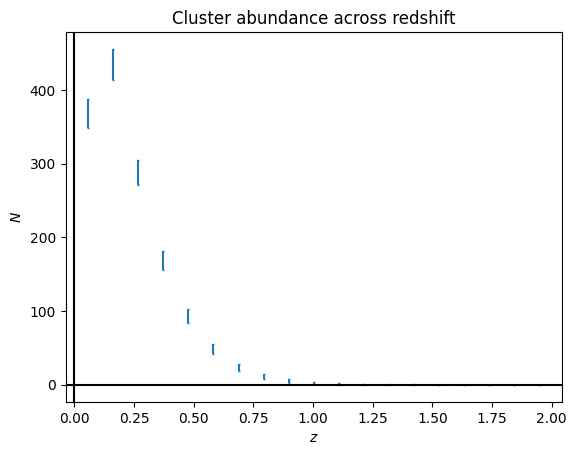

In [27]:
size_marker = 1

pl.errorbar(bins_centres_snr,n_binned_snr_theory,yerr=np.sqrt(n_binned_snr_theory),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.axvline(x=5.,color="k")
pl.axhline(y=0.,color="k")
pl.title("Cluster counts across SNR (selection observable)")
pl.show()

pl.errorbar(bins_centres_z,n_binned_z_theory,yerr=np.sqrt(n_binned_z_theory),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$z$")
pl.ylabel("$N$")
pl.axvline(x=0.,color="k")
pl.axhline(y=0.,color="k")
pl.title("Cluster abundance across redshift")
pl.show()

In [28]:
bins_centres_z

array([0.0575, 0.1625, 0.2675, 0.3725, 0.4775, 0.5825, 0.6875, 0.7925,
       0.8975, 1.0025, 1.1075, 1.2125, 1.3175, 1.4225, 1.5275, 1.6325,
       1.7375, 1.8425, 1.9475])

# Cluster abundance in tszpower

In [29]:
# use cosmocnc binning information
z_edges = jnp.asarray(cnc_params["bins_edges_z"])
q_edges = jnp.asarray(cnc_params["bins_edges_obs_select"])

Nz, Nq = tsz.compute_cluster_counts_in_z_q_bins_completeness(
    params_values_dict=allpars,
    sigma_lnY=0.173,
    # z binning
    z_edges=z_edges,
    # q / SNR binning
    q_edges=q_edges,
    f_sky=1.0,
    n_grid=4096,
    nsig=50.0,
)


In [30]:
Nz.shape, Nq.shape

((19,), (19,))

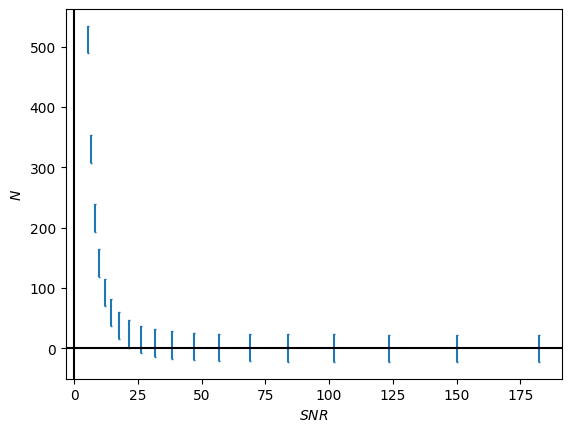

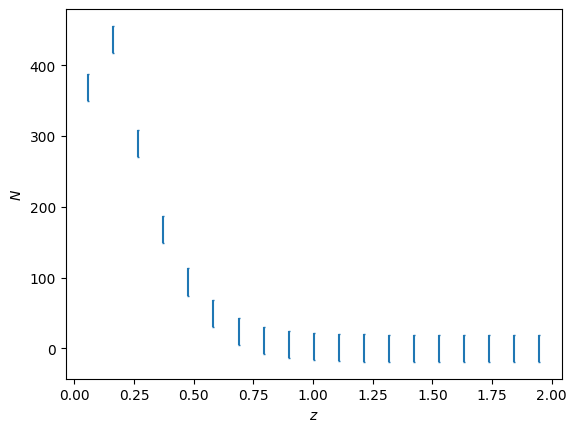

In [31]:
size_marker = 1

pl.errorbar(bins_centres_snr,Nq,yerr=np.sqrt(Nq[0]),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.axvline(x=0.,color="k")
pl.axhline(y=0.,color="k")

pl.show()

pl.errorbar(bins_centres_z,Nz,yerr=np.sqrt(Nz[0]),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$z$")
pl.ylabel("$N$")

pl.show()



# Compare tszpower witt cosmocnc

In [32]:
Nq/n_binned_snr_theory

Array([1.00185225, 1.00123969, 1.00121607, 1.00118671, 1.00113013,
       1.0011015 , 1.00110224, 1.00109349, 1.00108637, 1.0010689 ,
       1.00105788, 1.00105349, 1.00104923, 1.00104208, 1.00102873,
       1.00101006, 1.00098519, 1.00095146, 1.00090658], dtype=float64)

In [33]:
Nz/n_binned_z_theory


Array([1.00076254, 1.00303723, 1.0025974 , 0.99243394, 1.01055249,
       1.01182103, 0.98681177, 0.97067023, 1.0111565 , 1.01672282,
       1.00174804, 1.01584379, 1.05113551, 1.04660943, 0.90291867,
       1.0597936 , 1.03571728, 0.96023473, 0.99753766], dtype=float64)

In [34]:
np.sum(n_binned_snr_theory)
np.sum(Nz)
# np.sum(n_binned_z_theory)
# np.sum(Nq)

Array(1448.28985785, dtype=float64)

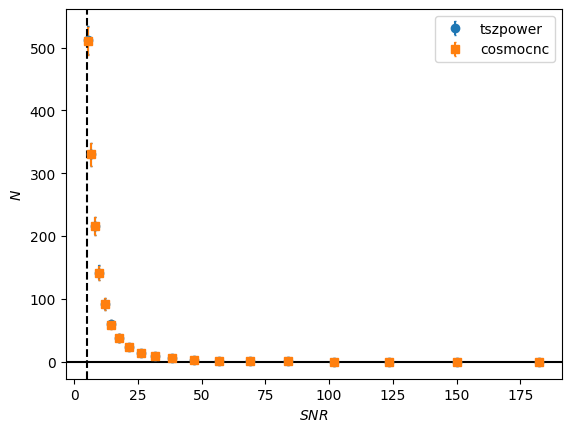

In [35]:
size_marker = 1

pl.figure()

# tszpower
pl.errorbar(
    bins_centres_snr,
    Nq,
    yerr=np.sqrt(Nq),
    color="tab:blue",
    linestyle="none",
    fmt="o",
    capsize=size_marker,
    label="tszpower",
)

# cosmocnc
pl.errorbar(
    bins_centres_snr,
    n_binned_snr_theory,
    yerr=np.sqrt(n_binned_snr_theory),
    color="tab:orange",
    linestyle="none",
    fmt="s",
    capsize=size_marker,
    label="cosmocnc",
)

pl.axvline(x=5.0, color="k", linestyle="--")
pl.axhline(y=0.0, color="k")

pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.legend()
pl.show()


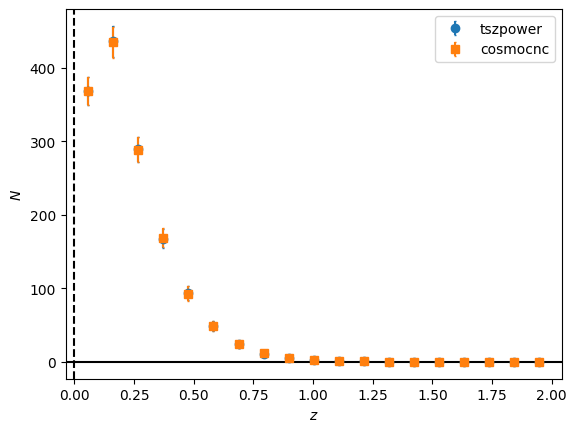

In [36]:
pl.figure()

# tszpower
pl.errorbar(
    bins_centres_z,
    Nz,
    yerr=np.sqrt(Nz),
    color="tab:blue",
    linestyle="none",
    fmt="o",
    capsize=size_marker,
    label="tszpower",
)

# cosmocnc
pl.errorbar(
    bins_centres_z,
    n_binned_z_theory,
    yerr=np.sqrt(n_binned_z_theory),
    color="tab:orange",
    linestyle="none",
    fmt="s",
    capsize=size_marker,
    label="cosmocnc",
)

pl.axvline(x=0.0, color="k", linestyle="--")
pl.axhline(y=0.0, color="k")

pl.xlabel("$z$")
pl.ylabel("$N$")
pl.legend()
pl.show()
